# Zadání I. seminární práce z předmětu Počítačové zpracování signálu (KI/PZS)
Autor: Aleksandr Demin (F24343)


## 2 - Výpočet korelace měřených signálů

#### 1 - Importy

In [1]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import detrend, resample, correlate
from scipy.interpolate import interp1d
from scipy.stats import pearsonr
import pandas as pd

import os

#### 2 - Načtení dat a vizualizace

In [77]:
file_path = "C:\\Users\\alecs\\Files\\UJEP\\PZS\\SemPrace1\\data\\charis-database-1.0.0\\charis-database-1.0.0"
record = wfdb.rdrecord(file_path + "\\charis6")
fs = record.fs
signals = record.p_signal
channel_names = record.sig_name

In [78]:
print("Channels:", channel_names)
print("Sampling rate:", fs, "Hz")

Channels: ['ABP', 'ECG', 'ICP']
Sampling rate: 50 Hz


In [79]:
abp = signals[:, 0]
ecg = signals[:, 1]
icp = signals[:, 2]

t = np.arange(len(ecg)) / fs

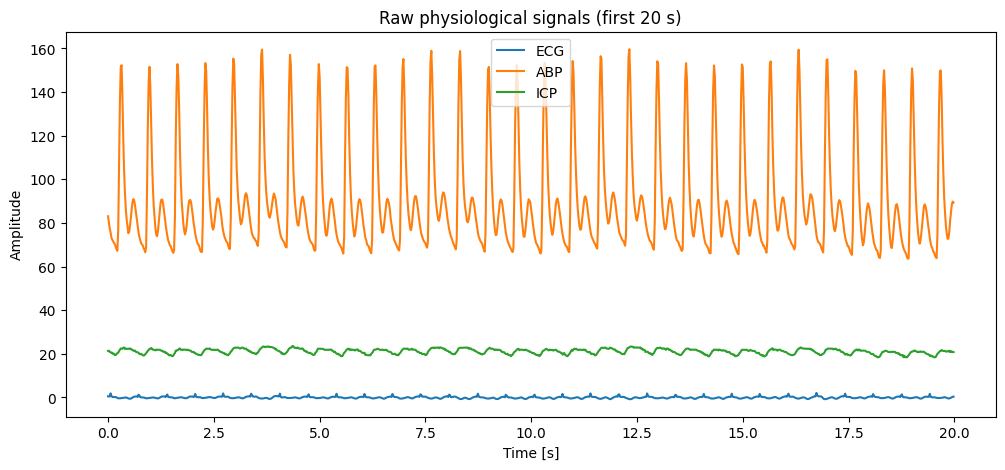

In [80]:
plt.figure(figsize=(12, 5))
plt.plot(t[:fs*20], ecg[:fs*20], label='ECG')
plt.plot(t[:fs*20], abp[:fs*20], label='ABP')
plt.plot(t[:fs*20], icp[:fs*20], label='ICP')
plt.title('Raw physiological signals (first 20 s)')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.legend()
plt.show()

Jak zde vidím, kanály nejsou centralizované a vykazují trend, takže je třeba je předem ošetřit

Jak jsem se později dozvěděl, u některých pacientů může být jeden z kanálů prázdný (obvykle ABP).

### 3. Předzpracování 

- 1️. Pouze první hodina signalu
- 2️. Interpolace pro chybějící hodnoty
- 3️. Detrendovaní a centralizovaní
- 4️. Převzorkovaní na společnou frekvenci (volitelné, pokud všechny mají stejnou fs)


In [3]:

def preprocess(signal, fs, new_fs=None):
    # Use only first hour
    signal = signal[:int(fs * 3600)]

    # Handle NaNs via interpolation
    if np.isnan(signal).any():
        idx = np.arange(len(signal))
        mask = ~np.isnan(signal)
        f = interp1d(idx[mask], signal[mask], bounds_error=False, fill_value="extrapolate")
        signal = f(idx)

    # Detrend and centralize
    signal = detrend(signal)
    signal = signal - np.mean(signal)

    # Resample if needed
    if new_fs and new_fs != fs:
        new_len = int(len(signal) * new_fs / fs)
        signal = resample(signal, new_len)
        fs = new_fs

    return signal, fs

[0.42620109 0.33877523 0.3934164  ... 0.07649763 0.         0.        ] [-0.02959638 -0.03436469 -0.02992523 ...  0.03222717  0.03699548
  0.01660686] [21.97365541 22.04503707 22.04503707 ... 20.71257935 21.18845711
 20.98620906]


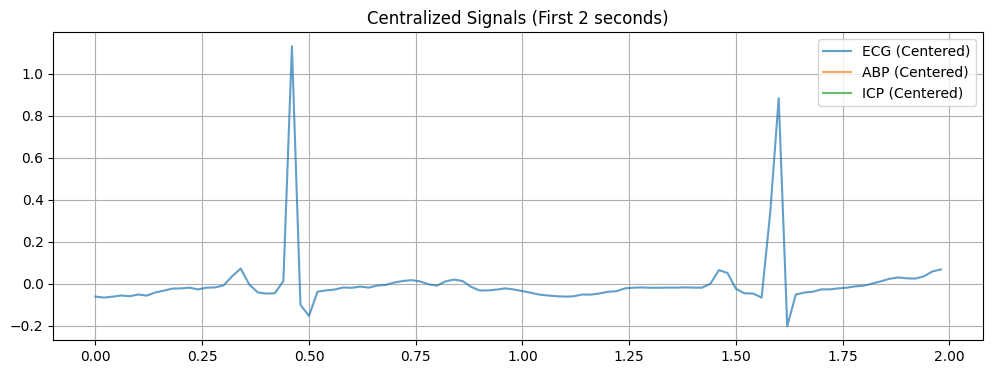

In [12]:
base_folder = "./data/charis-database-1.0.0"
record_path = os.path.join(base_folder, "charis4")
signals, fields = wfdb.rdsamp(record_path)
fs = fields["fs"]
abp = signals[:, 0]
ecg = signals[:, 1]
icp = signals[:, 2]
print(abp, ecg, icp)
ecg, fs = preprocess(ecg, fs)
abp, fs = preprocess(abp, fs)
icp, fs = preprocess(icp, fs)

t_x = np.arange(len(ecg)) / fs
plt.figure(figsize=(12, 4))
plt.plot(t_x[: fs*2], ecg[: fs*2], label='ECG (Centered)', alpha=0.7)
plt.plot(t_x[200: fs*2],abp[200: fs*2], label='ABP (Centered)', alpha=0.7)
plt.plot(t_x[200: fs*2],icp[200: fs*2], label='ICP (Centered)', alpha=0.7)
plt.legend()
plt.title("Centralized Signals (First 2 seconds)")
plt.grid(True)
plt.show()


In [7]:
ecg, fs = preprocess(ecg, fs)
abp, fs = preprocess(abp, fs)
icp, fs = preprocess(icp, fs)


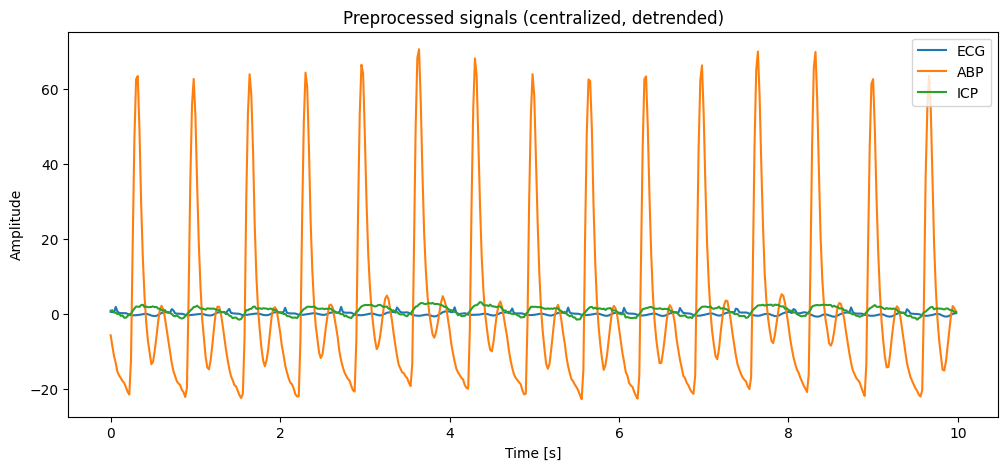

In [83]:
plt.figure(figsize=(12, 5))
t = np.arange(len(ecg)) / fs
plt.plot(t[:fs*10], ecg[:fs*10], label='ECG')
plt.plot(t[:fs*10], abp[:fs*10], label='ABP')
plt.plot(t[:fs*10], icp[:fs*10], label='ICP')
plt.title('Preprocessed signals (centralized, detrended)')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.legend()
plt.show()

Zde jsou předzpracované signály. Závislost jednotlivých signálů na sobě však není viditelná. K tomu je třeba vypočítat korelační koeficient.

### 4 - Výpočet korelačního koeficientu pomocí Pearson a Cross-Correlation metodu

In [97]:
def compute_pairwise_correlations(ecg, abp, icp):
    r_ecg_abp, _ = pearsonr(ecg, abp)
    r_ecg_icp, _ = pearsonr(ecg, icp)
    r_abp_icp, _ = pearsonr(abp, icp)

    results = pd.DataFrame({
        'Signal pair': ['ECG–ABP', 'ECG–ICP', 'ABP–ICP'],
        'Correlation (r)': [r_ecg_abp, r_ecg_icp, r_abp_icp]
    })
    return results


In [98]:
corr_table = compute_pairwise_correlations(ecg, abp, icp)
display(corr_table)

,Signal pair,Correlation (r)
0,ECG–ABP,0.026714
1,ECG–ICP,-0.006495
2,ABP–ICP,0.036625


Jak zde vidím, korelace je velmi slabá, ale to není pravda. Ve skutečnosti by korelace měla být silná. Mohlo by existovat několik možných příčin: špatná data, špatné zpracování signálu nebo chyba ve výpočtu.

Pearson metoda vypočítává korelaci ve stejných časových bodech pro dvě proměnné. Pokud hledáme vztah mezi signály, nemusí být okamžitý, ale spíše zpožděný v důsledku fyziologických faktorů. Proto má smysl provést Cross-Correlation, která odhalí, zda existuje korelace v čase.

### 4.1 - Cross-Correlation
Dále budou vypočítány korelační koeficienty mezi signály ECG a ABP; ABP a ICP; ECG a ICP pro jednoho pacienta.

In [100]:
def lagged_cross_correlation(x, y, fs, max_lag_s=5):
    # Normalize
    x = (x - np.mean(x)) / np.std(x)
    y = (y - np.mean(y)) / np.std(y)
    
    corr = correlate(y, x, mode='full')
    lags = np.arange(-len(x)+1, len(y))
    lags_sec = lags / fs

    # Limit to ±max_lag_s
    mask = (lags_sec >= -max_lag_s) & (lags_sec <= max_lag_s)
    corr = corr[mask]
    lags_sec = lags_sec[mask]

    lag_max = lags_sec[np.argmax(corr)]
    corr_max = np.max(corr) / len(x)
    return lags_sec, corr, lag_max, corr_max

In [ ]:
lags, corr_vals, lag_max, corr_max = lagged_cross_correlation(ecg, abp, fs, max_lag_s=5)


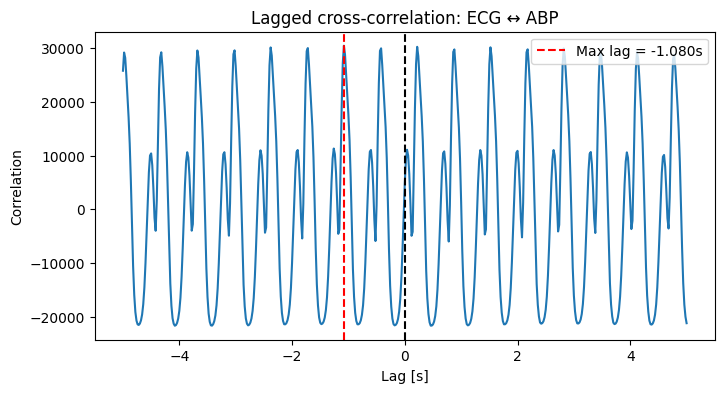

Maximum correlation = 0.169 at lag = -1.080 seconds


In [103]:
plt.figure(figsize=(8,4))
plt.plot(lags, corr_vals)
plt.axvline(0, color='k', linestyle='--')
plt.axvline(lag_max, color='r', linestyle='--', label=f'Max lag = {lag_max:.3f}s')
plt.title('Lagged cross-correlation: ECG ↔ ABP')
plt.xlabel('Lag [s]')
plt.ylabel('Correlation')
plt.legend()
plt.show()

print(f"Maximum correlation = {corr_max:.3f} at lag = {lag_max:.3f} seconds")

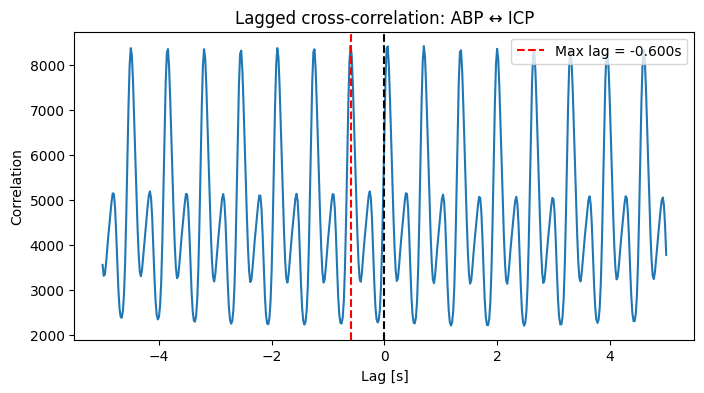

Maximum correlation = 0.047 at lag = -0.600 seconds


In [104]:
lags, corr_vals, lag_max, corr_max = lagged_cross_correlation(abp, icp, fs, max_lag_s=5)
plt.figure(figsize=(8,4))
plt.plot(lags, corr_vals)
plt.axvline(0, color='k', linestyle='--')
plt.axvline(lag_max, color='r', linestyle='--', label=f'Max lag = {lag_max:.3f}s')
plt.title('Lagged cross-correlation: ABP ↔ ICP')
plt.xlabel('Lag [s]')
plt.ylabel('Correlation')
plt.legend()
plt.show()
print(f"Maximum correlation = {corr_max:.3f} at lag = {lag_max:.3f} seconds")

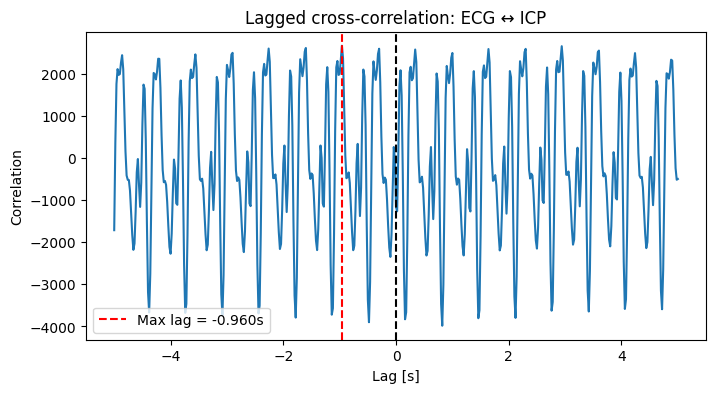

Maximum correlation = 0.015 at lag = -0.960 seconds


In [105]:
lags, corr_vals, lag_max, corr_max = lagged_cross_correlation(ecg, icp, fs, max_lag_s=5)
plt.figure(figsize=(8,4))
plt.plot(lags, corr_vals)
plt.axvline(0, color='k', linestyle='--')
plt.axvline(lag_max, color='r', linestyle='--', label=f'Max lag = {lag_max:.3f}s')
plt.title('Lagged cross-correlation: ECG ↔ ICP')
plt.xlabel('Lag [s]')
plt.ylabel('Correlation')
plt.legend()
plt.show()
print(f"Maximum correlation = {corr_max:.3f} at lag = {lag_max:.3f} seconds")

Jak zde vidím, korelační koeficienty se zvýšily, ale stále jsou malé. Vidím v tom několik problémů: špatné předzpracování signálu, chyba ve výpočtu nebo jiné příčiny

Mám však další hypotézu. Vzhledem k tomu, že data byla shromážděna od lidí s poraněním mozku (TBI - traumatic brain injury), mohou mít nějaká postižení, takže data nejsou reprezentativní.

Níže jsem vypočítal korelační koeficient pro každého pacienta.

### 4.2 - Cross-Correlation pro všechny pacienty

In [107]:
patients = ['charis1', 'charis2', 'charis3', 'charis4', 'charis5', 'charis6', 'charis7', 'charis8', 'charis9', 'charis10', 'charis11', 'charis12', 'charis13']

abp_signals = {}
ecg_signals = {}
icp_signals = {}

results_ecg = {}
results_abp = {}
results_icp = {}

for patient in patients:
    record = wfdb.rdrecord(file_path + f"\\{patient}")
    fs = record.fs
    signals = record.p_signal

    abp = signals[:, 0]
    ecg = signals[:, 1]
    icp = signals[:, 2]

    ecg, fs = preprocess(ecg, fs)
    abp, fs = preprocess(abp, fs)
    icp, fs = preprocess(icp, fs)

    abp_signals[patient] = abp
    ecg_signals[patient] = ecg
    icp_signals[patient] = icp

    lags_ecg_abp, corr_ecg_abp, lag_max_ecg_abp, corr_max_ecg_abp = lagged_cross_correlation(ecg, abp, fs, max_lag_s=5)
    results_ecg[patient] = (lag_max_ecg_abp, corr_max_ecg_abp)
    lags_abp_icp, corr_abp_icp, lag_max_abp_icp, corr_max_abp_icp = lagged_cross_correlation(abp, icp, fs, max_lag_s=5)
    results_abp[patient] = (lag_max_abp_icp, corr_max_abp_icp)
    lags_ecg_icp, corr_ecg_icp, lag_max_ecg_icp, corr_max_ecg_icp = lagged_cross_correlation(ecg, icp, fs, max_lag_s=5)
    results_icp[patient] = (lag_max_ecg_icp, corr_max_ecg_icp)

def create_results_table(results, signal_pair):
    data = {
        'Patient': [],
        'Max Lag (s)': [],
        'Max Correlation': []
    }
    for patient, (lag, corr) in results.items():
        data['Patient'].append(patient)
        data['Max Lag (s)'].append(lag)
        data['Max Correlation'].append(corr)
    df = pd.DataFrame(data)
    df.insert(0, 'Signal Pair', signal_pair)
    return df

table_ecg_abp = create_results_table(results_ecg, 'ECG–ABP')
table_abp_icp = create_results_table(results_abp, 'ABP–ICP')
table_ecg_icp = create_results_table(results_icp, 'ECG–ICP')
final_table = pd.concat([table_ecg_abp, table_abp_icp, table_ecg_icp], ignore_index=True)
display(final_table)



,Signal Pair,Patient,Max Lag (s),Max Correlation
0,ECG–ABP,charis1,0.00,0.030521
1,ECG–ABP,charis2,0.28,0.389341
2,ECG–ABP,charis3,0.92,0.171718
3,ECG–ABP,charis4,0.00,0.023756
4,ECG–ABP,charis5,0.00,0.023048
5,ECG–ABP,charis6,0.26,0.566420
6,ECG–ABP,charis7,0.30,0.326604
7,ECG–ABP,charis8,0.26,0.255417
8,ECG–ABP,charis9,0.58,0.147569
9,ECG–ABP,charis10,0.02,0.304985


Jak ukazuje tabulka, některé signály vykazují vysoké korelační koeficienty, například `charis3`, `charis10` a `charis11`. V průměru jsou však korelační hodnoty nízké.

### 5 - ABP korelace mezi pacienty

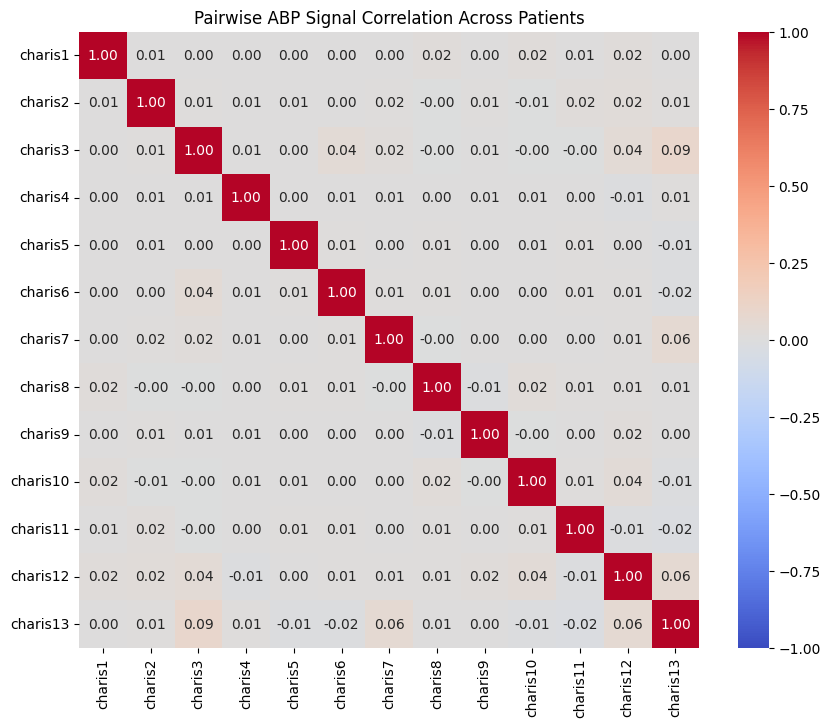

In [ ]:
patients = ['charis1', 'charis2', 'charis3', 'charis4', 'charis5', 'charis6', 'charis7', 'charis8', 'charis9', 'charis10', 'charis11', 'charis12', 'charis13']

abp_signals = {}
for patient in patients:
    record = wfdb.rdrecord(f"{file_path}\\{patient}")
    abp = record.p_signal[:, 0]
    abp, _ = preprocess(abp, record.fs)
    abp_signals[patient] = abp

N = len(abp_signals)
corr_matrix = np.zeros((N, N))
for i, p1 in enumerate(patients):
    for j, p2 in enumerate(patients):
        _, corr_max = lagged_cross_correlation(abp_signals[p1], abp_signals[p2], fs, max_lag_s=5)[2:4]
        corr_matrix[i, j] = corr_max

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, xticklabels=patients, yticklabels=patients, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Pairwise ABP Signal Correlation Across Patients')
plt.show()



Z grafu vyplývá, že korelační koeficient mezi jednotlivými pacienty je velmi nízký, což naznačuje, že mezi jednotlivými pacienty neexistuje žádný vztah a ukazatel ABP je pro každého individuální


### 6 - Závěr

U pacientů s traumatickým poraněním mozku (TBI) má vazba mezi krevním tlakem (ABT) a intrakraniálním tlakem (ICP) zvláštní diagnostický význam, protože narušená mozková autoregulace nebo změny v intrakraniální poddajnosti mohou ovlivnit jak sílu, tak načasování těchto korelací.
Detekované hodnoty zpoždění tak nejen potvrzují správnou synchronizaci signálu, ale také poskytují vhled do opožděné hemodynamické odpovědi v poraněném mozku.

